#爬取股票資料

In [13]:
import yfinance as yf
import pandas as pd
import os

# 建立存檔資料夾
data_folder = './data'
os.makedirs(data_folder, exist_ok=True)

# 設定股票代號
target_stock = '0050.TW'
print("正在從 Yahoo Finance 下載資料，請稍候...")

# 下載資料
df = yf.download(target_stock, start="2015-01-01")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 整理並儲存
df.reset_index(inplace=True)
filename = os.path.join(data_folder, '0050.csv')
df.to_csv(filename, index=False)

print(f"資料清洗完畢並順利儲存到：{filename}")
display(df.head())

/tmp/ipykernel_175/3826907877.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(target_stock, start="2015-01-01")
[*********************100%***********************]  1 of 1 completed

正在從 Yahoo Finance 下載資料，請稍候...
資料清洗完畢並順利儲存到：./data/0050.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Price,Date,Close,High,Low,Open,Volume
0,2015-01-05,11.721047,11.756272,11.624179,11.694629,25182448
1,2015-01-06,11.430444,11.580149,11.404025,11.580149,78007304
2,2015-01-07,11.448055,11.492086,11.395218,11.395218,27966168
3,2015-01-08,11.712244,11.729856,11.536120,11.536120,52614100
4,2015-01-09,11.650601,11.791500,11.632989,11.782694,23567924


#PPO模型與其他策略比較

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 835  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| time/                   |              |
|    fps                  | 561          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0061735706 |
|    clip_fraction        | 0.0825       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | -0.191       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.00502      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00531     |
|    std                  | 0.991        |
|    value_loss           | 0.000891     |
------------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 501          |
|    iterations           | 3            |
|    time_e

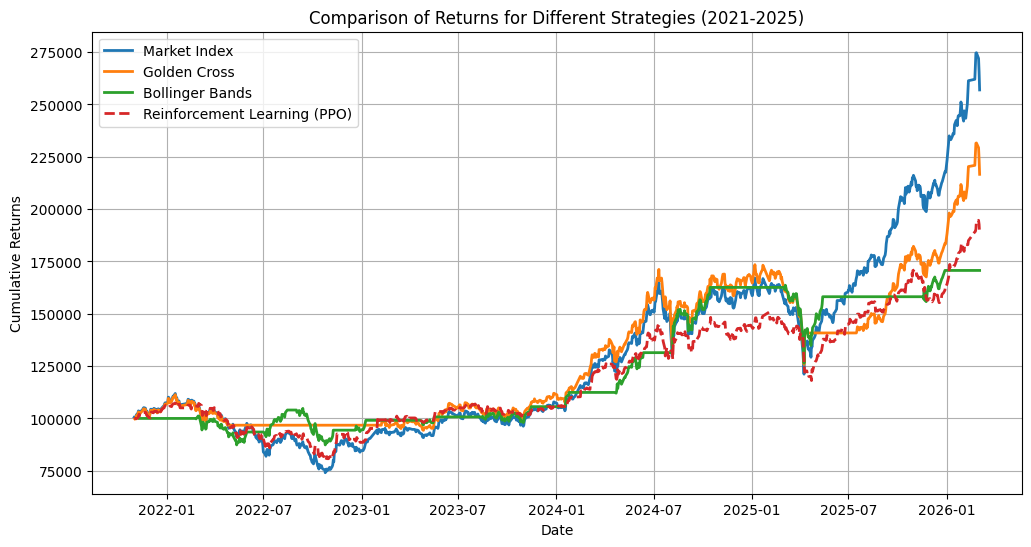

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import DummyVecEnv
from gym import Env
from gym.spaces import Box

file_path = './data/0050.csv'
data = pd.read_csv(file_path)


data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by='Date').reset_index(drop=True)
if 'Close' not in data.columns:
    raise ValueError("The 'Close' column is missing from the data.")

train_data = data[data['Date'] < '2021-01-01'].copy()
test_data = data[data['Date'] >= '2021-01-01'].copy()

# 計算技術指標
def add_features(dataset):
    dataset['MA_50'] = dataset['Close'].rolling(window=50).mean()  # 短期均線
    dataset['MA_200'] = dataset['Close'].rolling(window=200).mean()  # 長期均線
    dataset['Bollinger_Upper'] = dataset['Close'].rolling(window=20).mean() + 2 * dataset['Close'].rolling(window=20).std()
    dataset['Bollinger_Lower'] = dataset['Close'].rolling(window=20).mean() - 2 * dataset['Close'].rolling(window=20).std()
    dataset['Market_Return'] = dataset['Close'].pct_change()  # 日回報率
    dataset['Volatility'] = dataset['Close'].rolling(window=20).std()  # 波動率
    dataset['High_Low_Spread'] = dataset['High'] - dataset['Low']  # 當日高低價差
    dataset['Close_Open_Spread'] = dataset['Close'] - dataset['Open']  # 收盤與開盤差
    return dataset.dropna()

train_data = add_features(train_data)
test_data = add_features(test_data)

# 黃金交叉策略
test_data['Signal_GoldenCross'] = np.where(test_data['MA_50'] > test_data['MA_200'], 1, 0)
test_data['Position_GoldenCross'] = test_data['Signal_GoldenCross'].shift(1)
test_data['Strategy_Return_GoldenCross'] = test_data['Market_Return'] * test_data['Position_GoldenCross']

# 布林帶策略
test_data['Signal_Bollinger'] = np.where(test_data['Close'] < test_data['Bollinger_Lower'], 1,
                                         np.where(test_data['Close'] > test_data['Bollinger_Upper'], 0, np.nan))


test_data['Signal_Bollinger'] = test_data['Signal_Bollinger'].ffill()
test_data['Position_Bollinger'] = test_data['Signal_Bollinger'].shift(1)
test_data['Strategy_Return_Bollinger'] = test_data['Market_Return'] * test_data['Position_Bollinger']

# 定義強化學習環境
class StockTradingEnv(Env):
    def __init__(self, data, initial_balance=100000):
        super(StockTradingEnv, self).__init__()
        self.data = data
        self.initial_balance = initial_balance
        self.current_step = 0
        self.balance = initial_balance
        self.num_shares = 0
        self.net_worth = initial_balance
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)  # 動作空間：部分買入/賣出
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=(8,), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.num_shares = 0
        self.net_worth = self.initial_balance
        return self._next_observation()

    def _next_observation(self):
        row = self.data.iloc[self.current_step]

        obs = np.array([
            self.balance / self.initial_balance,
            self.num_shares / 1000.0,
            row['Close'] / 100.0,
            row['MA_50'] / 100.0,
            row['MA_200'] / 100.0,
            row['Bollinger_Upper'] / 100.0,
            row['Bollinger_Lower'] / 100.0,
            row['Volatility'] / 10.0
        ], dtype=np.float32)
        return obs

    def step(self, action):
        current_price = self.data.iloc[self.current_step]['Close']
        previous_net_worth = self.net_worth

        # 動作執行：部分買入/賣出
        if action > 0:  # 部分買入
            shares_to_buy = int(self.balance * action[0] / current_price)
            self.num_shares += shares_to_buy
            self.balance -= shares_to_buy * current_price
        elif action < 0:  # 部分賣出
            shares_to_sell = int(self.num_shares * abs(action[0]))
            self.num_shares -= shares_to_sell
            self.balance += shares_to_sell * current_price

        # 更新淨資產
        self.net_worth = self.balance + self.num_shares * current_price

        # 獎勵設計：基於資產增長率
        reward = (self.net_worth - previous_net_worth) / previous_net_worth

        transaction_penalty = abs(action[0]) * 0.0001
        reward -= transaction_penalty

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs = self._next_observation()
        return obs, reward, done, {}

    def render(self):
        print(f'Step: {self.current_step}, Net Worth: {self.net_worth}, Balance: {self.balance}, Shares: {self.num_shares}')

# 初始化訓練環境
env = DummyVecEnv([lambda: StockTradingEnv(train_data)])

# 訓練 PPO 模型
model = PPO('MlpPolicy', env, verbose=1, policy_kwargs=dict(net_arch=[256, 256]))
model.learn(total_timesteps=50000)

# 測試模型
env_test = StockTradingEnv(test_data)
obs = env_test.reset()
net_worths = []
for step in range(len(test_data) - 1):
    action, _states = model.predict(obs)
    obs, rewards, done, info = env_test.step(action)
    net_worths.append(env_test.net_worth)
    if done:
        break
test_data['Cumulative_RL'] = [env_test.initial_balance] + net_worths[:len(test_data) - 1]

# 計算累積收益
initial_capital = 100000
test_data['Cumulative_Market'] = (1 + test_data['Market_Return']).cumprod() * initial_capital
test_data['Cumulative_GoldenCross'] = (1 + test_data['Strategy_Return_GoldenCross']).cumprod() * initial_capital
test_data['Cumulative_Bollinger'] = (1 + test_data['Strategy_Return_Bollinger']).cumprod() * initial_capital

# 繪製收益比較圖
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_data['Cumulative_Market'], label='Market Index', linewidth=2)
plt.plot(test_data['Date'], test_data['Cumulative_GoldenCross'], label='Golden Cross', linewidth=2)
plt.plot(test_data['Date'], test_data['Cumulative_Bollinger'], label='Bollinger Bands', linewidth=2)
plt.plot(test_data['Date'], test_data['Cumulative_RL'], label='Reinforcement Learning (PPO)', linewidth=2, linestyle='--')

plt.legend()
plt.title('Comparison of Returns for Different Strategies (2021-2025)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid()
plt.show()